# Python Exploratory Data Analysis
## IBM Telco Customer Churn Dataset

This notebook performs comprehensive exploratory data analysis using Python visualization libraries to understand customer churn patterns and identify key drivers.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Create figures directory
figures_dir = Path('../reports/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported and figures directory created")

✓ Libraries imported and figures directory created


---
## 1. Load and Clean Data

Loading the Telco Customer Churn dataset from CSV and applying the same cleaning transformations:
- Convert blank TotalCharges to 0 and cast to float
- Convert Churn from Yes/No to 1/0

In [2]:
# Load data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Clean TotalCharges: convert blank strings to 0, cast to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"✓ Data loaded and cleaned: {df.shape[0]} rows, {df.shape[1]} columns")

✓ Data loaded and cleaned: 7043 rows, 21 columns


---
## 2. Dataset Overview

Understanding the structure, data types, and quality of our dataset.

In [3]:
# Dataset shape
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset Shape: (7043, 21)
Rows: 7,043
Columns: 21


In [4]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [5]:
# Missing values
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df['Missing Count'].sum() == 0:
    print("✓ No missing values found")


Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []
✓ No missing values found


In [6]:
# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates == 0:
    print("✓ No duplicate rows found")


Duplicate Rows: 0
✓ No duplicate rows found


In [7]:
# First few rows
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


---
## 3. Target Distribution

Analyzing the distribution of our target variable (Churn) to understand class balance.

In [8]:
# Calculate churn statistics
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"Retained (0): {churn_counts[0]:,} ({churn_pct[0]:.2f}%)")
print(f"Churned (1): {churn_counts[1]:,} ({churn_pct[1]:.2f}%)")

Churn Distribution:
Retained (0): 5,174 (73.46%)
Churned (1): 1,869 (26.54%)


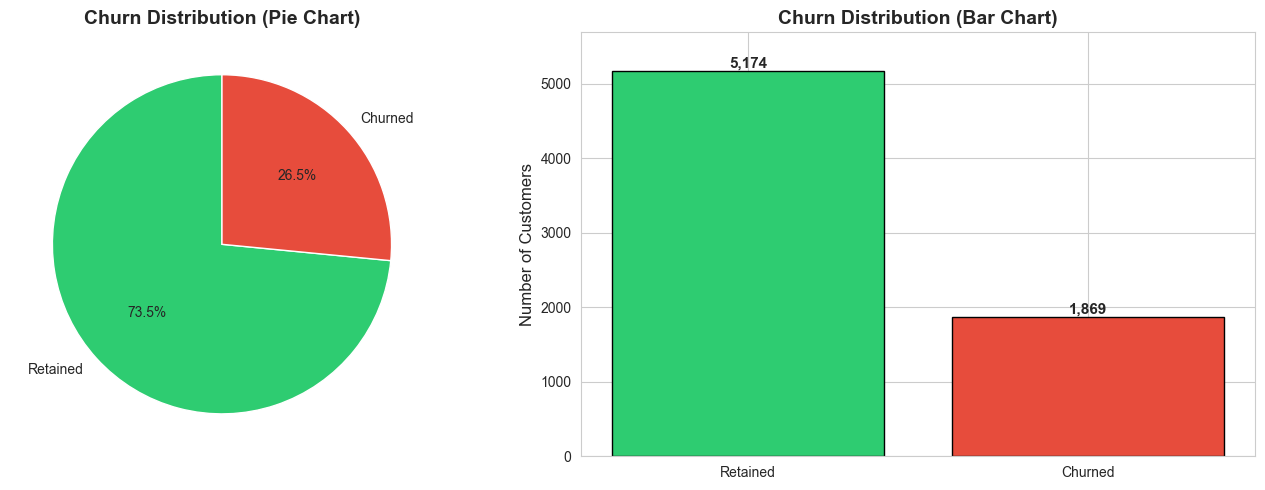

✓ Figure saved: target_distribution.png


In [9]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#2ecc71', '#e74c3c']  # Green for retained, red for churned
labels = ['Retained', 'Churned']
axes[0].pie(churn_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Churn Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(['Retained', 'Churned'], churn_counts, color=colors, edgecolor='black')
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].set_title('Churn Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(churn_counts) * 1.1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: target_distribution.png")

---
## 4. Numerical Feature Distributions

Examining the distribution of key numerical features split by churn status using KDE plots.

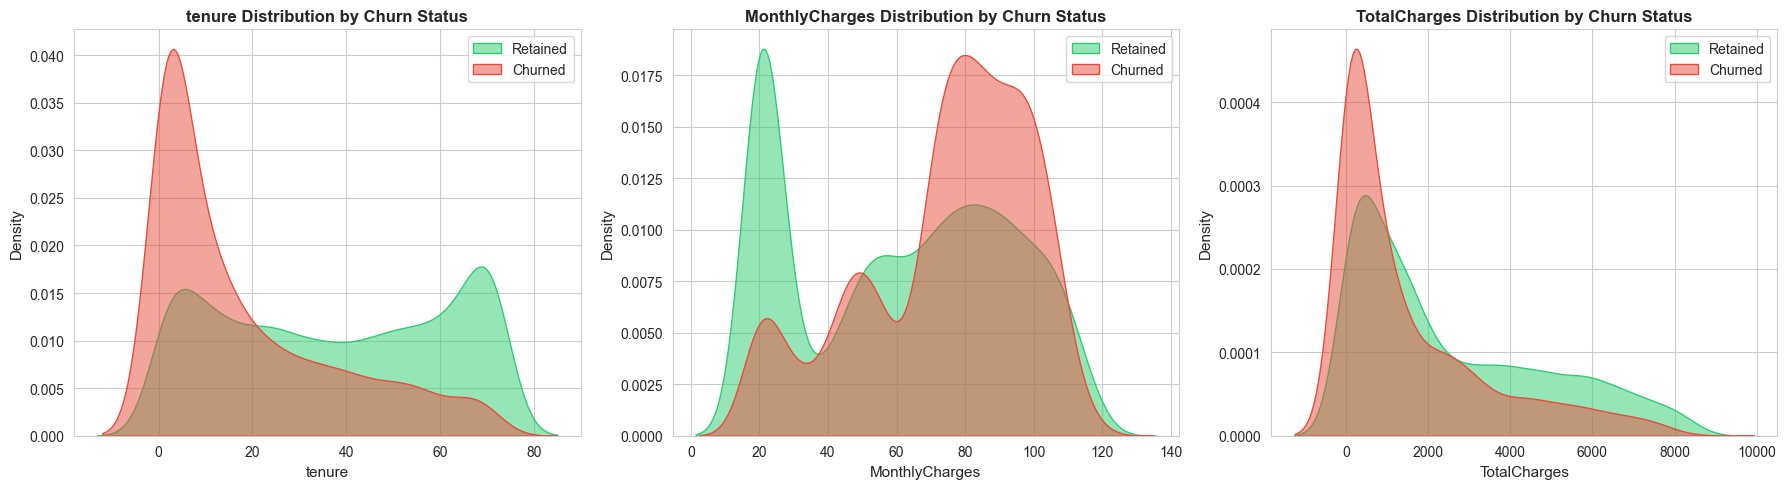

✓ Figure saved: numerical_distributions.png


In [10]:
# KDE plots for numerical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(numerical_features):
    # Plot for retained customers
    sns.kdeplot(data=df[df['Churn'] == 0], x=feature, 
                color='#2ecc71', fill=True, alpha=0.5, label='Retained', ax=axes[idx])
    
    # Plot for churned customers
    sns.kdeplot(data=df[df['Churn'] == 1], x=feature, 
                color='#e74c3c', fill=True, alpha=0.5, label='Churned', ax=axes[idx])
    
    axes[idx].set_title(f'{feature} Distribution by Churn Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Density', fontsize=11)
    axes[idx].legend()

plt.tight_layout()
plt.savefig(figures_dir / 'numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: numerical_distributions.png")

In [11]:
# Summary statistics by churn status
print("\nNumerical Features Summary by Churn Status:")
for feature in numerical_features:
    print(f"\n{feature}:")
    print(df.groupby('Churn')[feature].describe())


Numerical Features Summary by Churn Status:

tenure:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

MonthlyCharges:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
0      5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1      1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35

TotalCharges:
        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
0      5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
1      1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
Churn           
0      8672.45  
1      868

---
## 5. Categorical Features Analysis

Analyzing the relationship between key categorical features and churn rate using stacked bar charts.

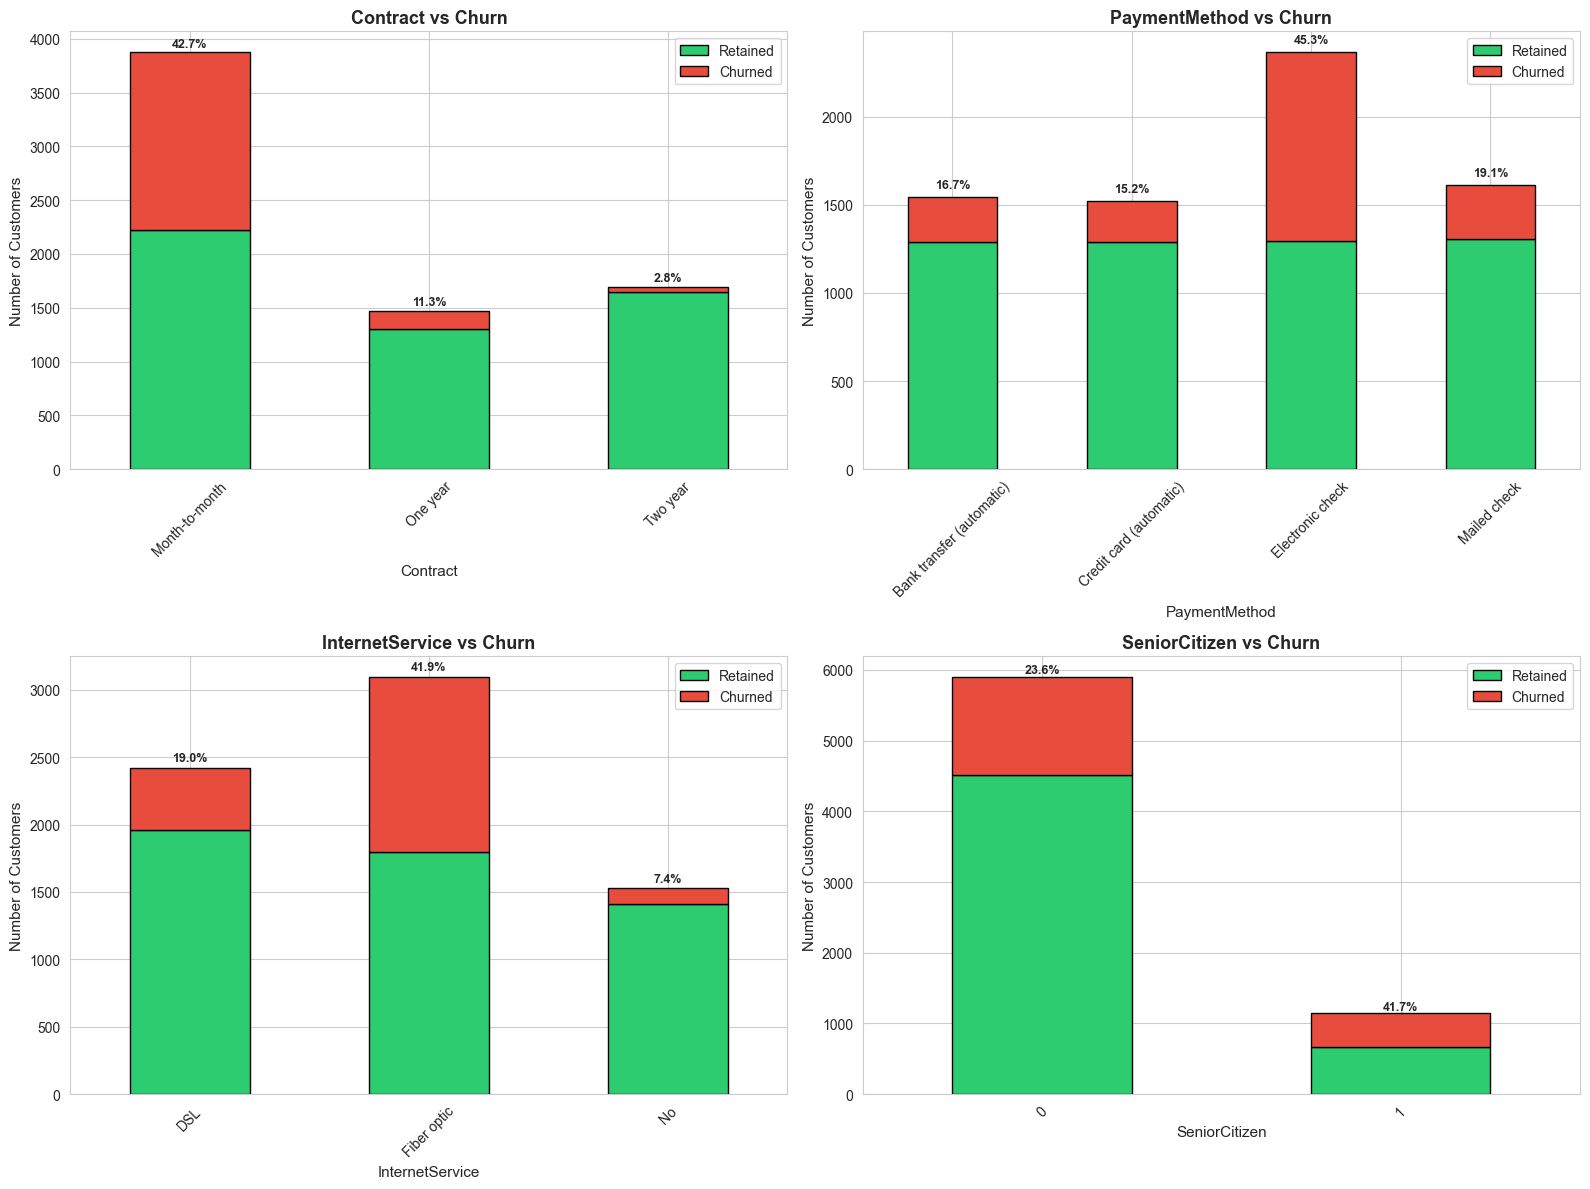

✓ Figure saved: categorical_features.png


In [12]:
# Categorical features to analyze
categorical_features = ['Contract', 'PaymentMethod', 'InternetService', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(categorical_features):
    # Create crosstab
    ct = pd.crosstab(df[feature], df['Churn'])
    
    # Create stacked bar chart
    ct.plot(kind='bar', stacked=True, ax=axes[idx], 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
    
    axes[idx].set_title(f'{feature} vs Churn', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Number of Customers', fontsize=11)
    axes[idx].legend(['Retained', 'Churned'], loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add churn rate annotations
    churn_rates = df.groupby(feature)['Churn'].mean() * 100
    for i, (category, rate) in enumerate(churn_rates.items()):
        axes[idx].text(i, ct.loc[category].sum() + 50, 
                      f'{rate:.1f}%', 
                      ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: categorical_features.png")

In [13]:
# Print churn rates for each category
print("\nChurn Rates by Categorical Features:")
for feature in categorical_features:
    print(f"\n{feature}:")
    churn_rate = df.groupby(feature)['Churn'].agg(['mean', 'count'])
    churn_rate['mean'] = churn_rate['mean'] * 100
    churn_rate.columns = ['Churn Rate (%)', 'Count']
    print(churn_rate.sort_values('Churn Rate (%)', ascending=False))


Churn Rates by Categorical Features:

Contract:
                Churn Rate (%)  Count
Contract                             
Month-to-month       42.709677   3875
One year             11.269518   1473
Two year              2.831858   1695

PaymentMethod:
                           Churn Rate (%)  Count
PaymentMethod                                   
Electronic check                45.285412   2365
Mailed check                    19.106700   1612
Bank transfer (automatic)       16.709845   1544
Credit card (automatic)         15.243101   1522

InternetService:
                 Churn Rate (%)  Count
InternetService                       
Fiber optic           41.892765   3096
DSL                   18.959108   2421
No                     7.404980   1526

SeniorCitizen:
               Churn Rate (%)  Count
SeniorCitizen                       
1                   41.681261   1142
0                   23.606168   5901


---
## 6. Correlation Analysis

Examining correlations between numerical features to identify potential multicollinearity and relationships.

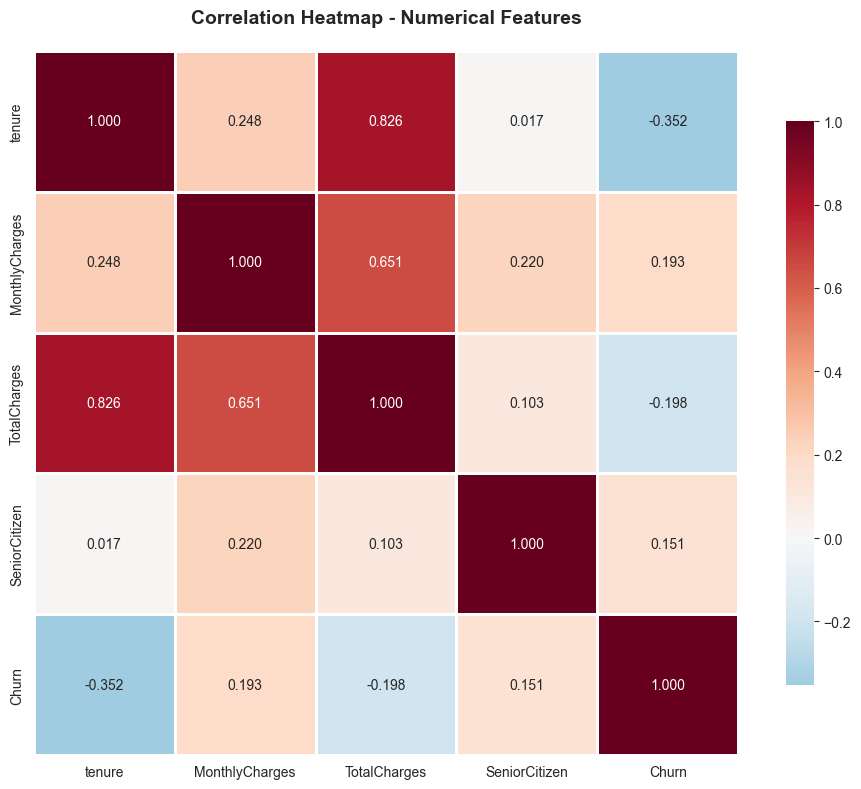

✓ Figure saved: correlation_heatmap.png


In [14]:
# Select numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr_matrix = df[numerical_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(figures_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: correlation_heatmap.png")

In [15]:
# Print strongest correlations with Churn
print("\nCorrelations with Churn (sorted by absolute value):")
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr)


Correlations with Churn (sorted by absolute value):
tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn, dtype: float64


---
## 7. Contract Type Analysis

Deep dive into how contract type affects monthly charges and tenure using boxplots.

C:\Users\gargd\AppData\Local\Temp\ipykernel_27584\3130016627.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Contract', y='MonthlyCharges',
C:\Users\gargd\AppData\Local\Temp\ipykernel_27584\3130016627.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Contract', y='tenure',


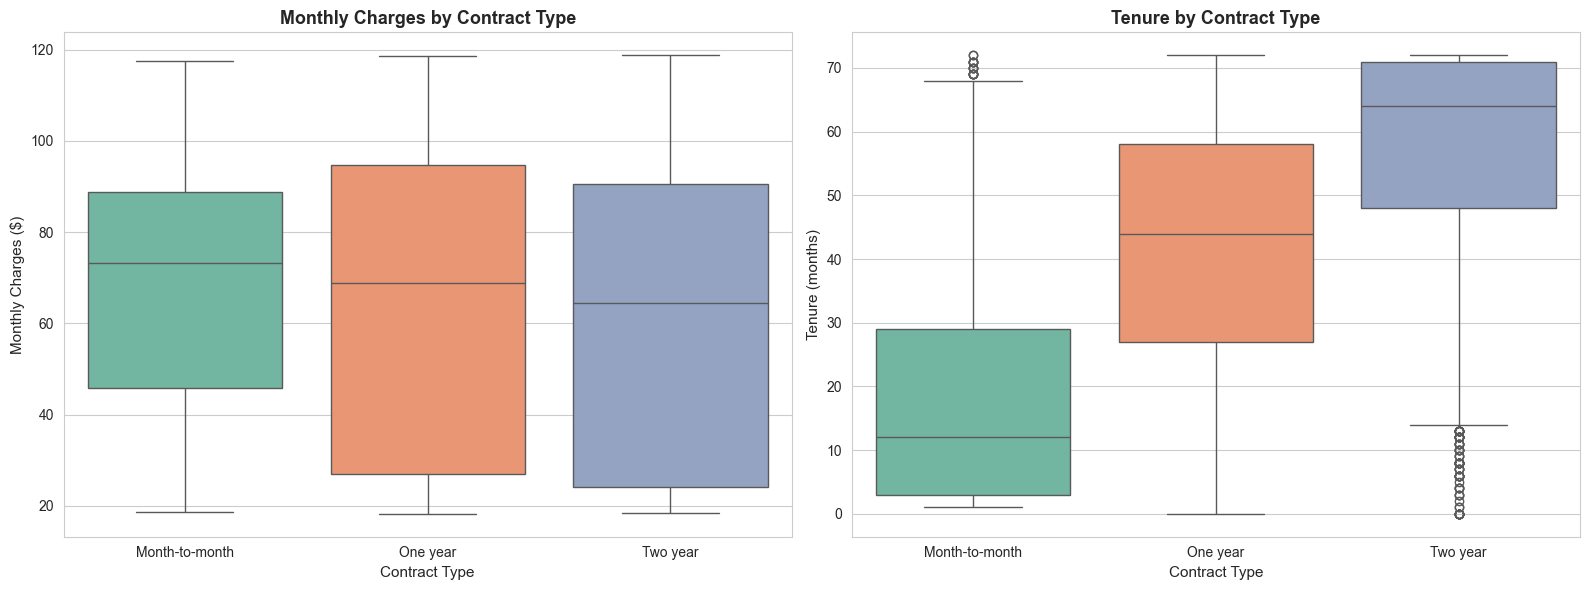

✓ Figure saved: contract_boxplots.png


In [16]:
# Boxplots for MonthlyCharges and tenure by Contract type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MonthlyCharges by Contract
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', 
            palette='Set2', ax=axes[0])
axes[0].set_title('Monthly Charges by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contract Type', fontsize=11)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=11)

# tenure by Contract
sns.boxplot(data=df, x='Contract', y='tenure', 
            palette='Set2', ax=axes[1])
axes[1].set_title('Tenure by Contract Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contract Type', fontsize=11)
axes[1].set_ylabel('Tenure (months)', fontsize=11)

plt.tight_layout()
plt.savefig(figures_dir / 'contract_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: contract_boxplots.png")

In [17]:
# Summary statistics by Contract type
print("\nMonthly Charges by Contract Type:")
print(df.groupby('Contract')['MonthlyCharges'].describe())

print("\nTenure by Contract Type:")
print(df.groupby('Contract')['tenure'].describe())


Monthly Charges by Contract Type:
                 count       mean        std    min     25%    50%     75%  \
Contract                                                                     
Month-to-month  3875.0  66.398490  26.926599  18.75  45.850  73.25  88.875   
One year        1473.0  65.048608  31.840539  18.25  26.900  68.75  94.800   
Two year        1695.0  60.770413  34.678865  18.40  24.025  64.35  90.450   

                   max  
Contract                
Month-to-month  117.45  
One year        118.60  
Two year        118.75  

Tenure by Contract Type:
                 count       mean        std  min   25%   50%   75%   max
Contract                                                                 
Month-to-month  3875.0  18.036645  17.689054  1.0   3.0  12.0  29.0  72.0
One year        1473.0  42.044807  19.035883  0.0  27.0  44.0  58.0  72.0
Two year        1695.0  56.735103  18.209363  0.0  48.0  64.0  71.0  72.0


---
## 8. Key Findings

Based on the exploratory data analysis, here are the most important patterns discovered:

- **High churn in month-to-month contracts**: Customers with month-to-month contracts show significantly higher churn rates compared to those with one-year or two-year contracts, indicating that contract commitment is a strong retention factor.

- **Tenure is inversely related to churn**: Customers with shorter tenure (0-12 months) are much more likely to churn. The longer a customer stays, the less likely they are to leave, suggesting the importance of early retention efforts.

- **Electronic check payment method shows elevated churn**: Customers using electronic check as their payment method exhibit higher churn rates compared to other payment methods, potentially indicating friction in the payment process.

- **Fiber optic internet customers churn more**: Despite potentially being a premium service, fiber optic internet customers show higher churn rates, which may indicate service quality issues or pricing concerns that need investigation.

- **Monthly charges are higher for churned customers**: Churned customers tend to have higher monthly charges on average, suggesting that price sensitivity may be a key driver of churn and that value perception needs improvement.

---
## Summary

This exploratory data analysis has provided comprehensive insights into the Telco customer churn dataset. All visualizations have been saved to the `reports/figures/` directory for future reference and reporting.

**Next Steps:**
- Feature engineering based on identified patterns
- Build predictive models
- Develop retention strategies targeting high-risk segments